In [52]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
# Added random_split to split the data

In [53]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: cuda


### Problem 4.1: Organize the Data
Data should be organized to facilitate training, testing, and validating a model 

In [54]:
# define the training and testing mechanisms to load in images as datasets
BATCH_SIZE = 10

train_transform_augmented = transforms.Compose([
    # Apply some random flips and rotation
    transforms.RandomResizedCrop(200, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p = 0.7), 
    transforms.RandomVerticalFlip(p = 0.7), 
    transforms.RandomRotation(degrees = 25),

    # Randomly apply color jitters or random perspectives
    transforms.RandomApply([
        transforms.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3, hue = 0.05),
        transforms.RandomPerspective(distortion_scale = 0.4, p = 1.0),
    ], p = 0.5),

    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

full_dataset_aug = datasets.ImageFolder("images", transform = train_transform_augmented)

train_size_aug = int(0.8 * len(full_dataset_aug))
test_size_aug = len(full_dataset_aug) - train_size_aug

train_dataset_augmented, test_dataset_augmented = random_split(full_dataset_aug, [train_size_aug, test_size_aug])
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset_augmented, batch_size=BATCH_SIZE, shuffle=False)

### Problem 4.2: Construct a CNN 
Implement a CNN in PyTorch with appropriate layers and a loss function

In [63]:
class ClassificationCNN(nn.Module):
    def __init__(self):
        super(ClassificationCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(p=0.1),
        
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(p=0.15),
        
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(p=0.2),
        
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(p=0.25)
        )
        
        conv_output_size = 128 * (12) * (12)
        self.fc_layers = nn.Sequential(
           nn.Flatten(),
            nn.Linear(conv_output_size, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(128, 8)
        )

    # define the forward step
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

### Problem 4.3: Training the CNN 
Implement a training loop to optimize the weights in the network

In [64]:
def compute_correct_labels(outputs, labels):
    correct = 0
    total = 0
    _, predicted_values = torch.max(outputs, 1)
    differences = predicted_values - labels
    for i in range(len(differences)):
        if differences[i]==0:
            correct +=1
        total += 1
    return(correct, total)

def training_loop(model, optimizer, NUM_EPOCHS, train_loader, test_loader, printing=True):
    # make empty lists to keep track of the training and testing losses
    train_losses = []
    test_losses = []
    
    # loop through each epoch to run the training loop
    # and check the model with the training data
    # keep track of both sets of losses as your go
    for epoch in range(NUM_EPOCHS):
        
        # Run the training loop
        model.train()
        total_train_loss = 0.0
        total_train_correct = 0
        total_train_images = 0
        for train_inputs, train_labels in train_loader:
            train_inputs, train_labels = train_inputs.to(device), train_labels.to(device)
            optimizer.zero_grad()
            outputs = model(train_inputs)
            train_correct, train_total = compute_correct_labels(outputs, train_labels)
            total_train_correct += train_correct
            total_train_images += train_total
            loss = criterion(outputs, train_labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Run the testing loop
        # this is essentially the same as the training loop but
        # without the optimizer and backward propagation
        model.eval()
        total_test_loss = 0.0
        total_test_correct = 0
        total_test_images = 0
        with torch.no_grad():
            for test_inputs, test_labels in test_loader:
                test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)
                outputs = model(test_inputs)
                test_correct, test_total = compute_correct_labels(outputs, test_labels)
                total_test_correct += test_correct
                total_test_images += test_total
                loss = criterion(outputs, test_labels)
                total_test_loss += loss.item()
        avg_test_loss = total_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        if printing:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}"+\
                  f" - Train Loss: {avg_train_loss:.4f}, "+\
                  f"Train Correct: {total_train_correct}/{total_train_images} "+\
                  f"- Test Loss: {avg_test_loss:.4f}, "+\
                  f"Test Correct: {total_test_correct}/{total_test_images} ")

    return(train_losses, test_losses)

model = ClassificationCNN().to(device)

criterion = nn.CrossEntropyLoss()

# Adam optimizer for stochastic gradient descent
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# define the number of epochs
NUM_EPOCHS = 200

# call the training loop function we defined above
train_losses, test_losses = training_loop(model, optimizer, NUM_EPOCHS, train_loader_augmented, test_loader, printing = True)

Epoch 1/200 - Train Loss: 2.0787, Train Correct: 80/607 - Test Loss: 2.0509, Test Correct: 22/152 
Epoch 2/200 - Train Loss: 2.0603, Train Correct: 90/607 - Test Loss: 2.0425, Test Correct: 22/152 
Epoch 3/200 - Train Loss: 2.0396, Train Correct: 93/607 - Test Loss: 2.0446, Test Correct: 32/152 
Epoch 4/200 - Train Loss: 2.0021, Train Correct: 115/607 - Test Loss: 2.0060, Test Correct: 35/152 
Epoch 5/200 - Train Loss: 1.9659, Train Correct: 117/607 - Test Loss: 2.0141, Test Correct: 30/152 
Epoch 6/200 - Train Loss: 1.9531, Train Correct: 145/607 - Test Loss: 1.9583, Test Correct: 43/152 
Epoch 7/200 - Train Loss: 1.9164, Train Correct: 138/607 - Test Loss: 1.9064, Test Correct: 42/152 
Epoch 8/200 - Train Loss: 1.8944, Train Correct: 139/607 - Test Loss: 1.9081, Test Correct: 47/152 
Epoch 9/200 - Train Loss: 1.9026, Train Correct: 134/607 - Test Loss: 1.9812, Test Correct: 38/152 
Epoch 10/200 - Train Loss: 1.8959, Train Correct: 141/607 - Test Loss: 1.8738, Test Correct: 43/152 
Ep

### Problem 4.4: Assess the results of the CNN training 
Plot model losses and compute other metrics for model performance. Based on performance, modify the model architecture and training to test different implementations of the model and improve the model results. Be sure to visualize some of the images and their true vs predicted labels in addition to the model metrics. 

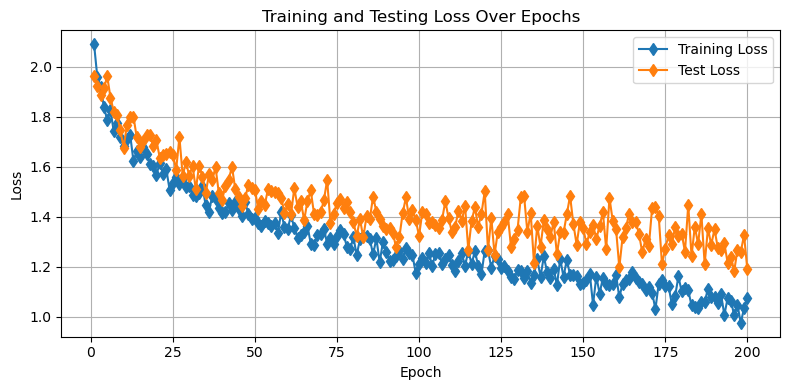

In [57]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, 'd-', label='Training Loss')
plt.plot(range(1, NUM_EPOCHS + 1), test_losses, 'd-', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

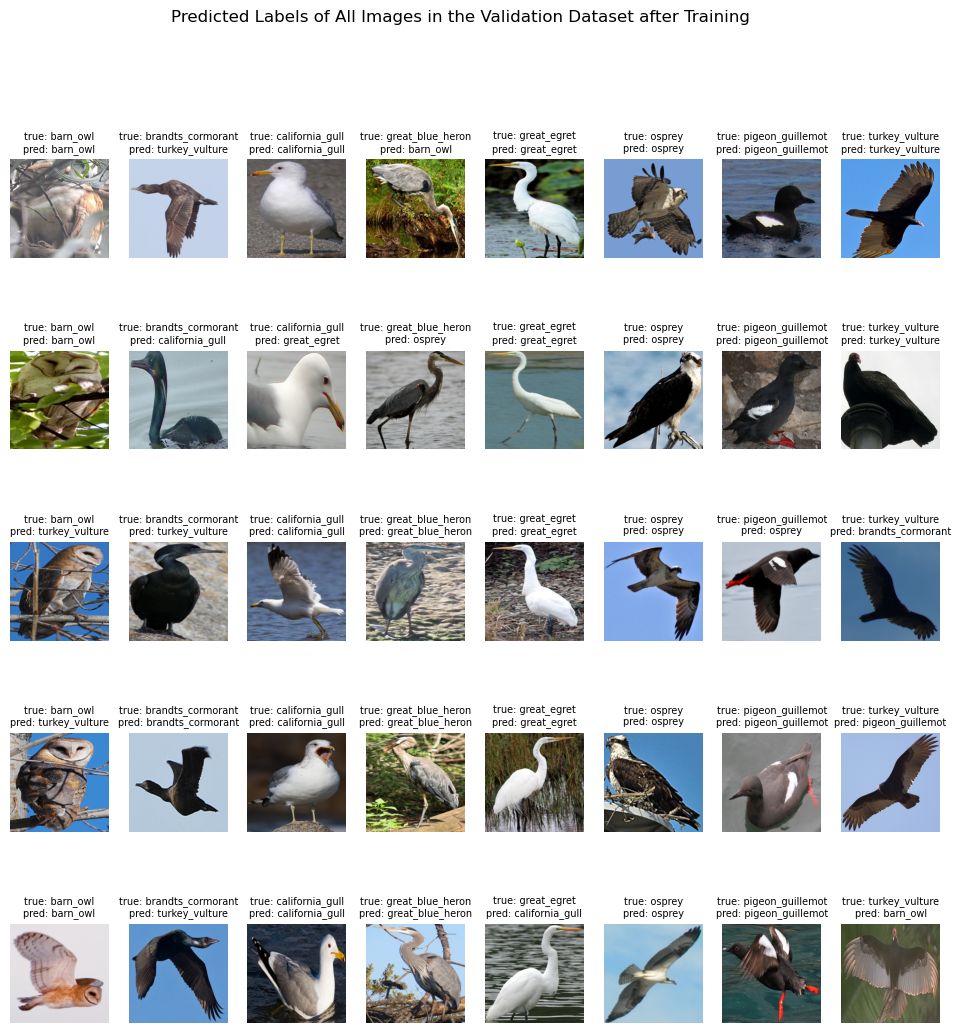

In [58]:
# define the species for each category
species = ['barn_owl','brandts_cormorant','california_gull','great_blue_heron','great_egret', 'osprey', 'pigeon_guillemot', 'turkey_vulture']

# Set model to evaluation mode
model.eval()

# make a figure object
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(5, len(species))

# loop through each species (column)
for s in range(len(species)):

    # loop through the image files
    file_list = os.listdir(os.path.join('images', species[s]))[:5]
    for file_count, file_name in enumerate(file_list):

        # load the image
        image = Image.open(os.path.join('images', species[s], file_name)).convert('RGB')
        input_tensor = train_transform_augmented(image).unsqueeze(0).to(device)  # Add batch dimension
        
        # get the predicted class
        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)
        predicted_class = species[predicted.item()]
        true_class = species[s]

        # add the image to the plot with the prediction
        ax = fig.add_subplot(gs[file_count, s])
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(f"true: {true_class}\npred: {predicted_class}", fontsize=7)
        file_count +=1

plt.suptitle('Predicted Labels of All Images in the Validation Dataset after Training')
plt.show()

### Problem 4.5: Describe the training process and the performance of the final  model
Write a paragraph describing your approach to constructing your CNN. Explain some of the issues that arose in building your network and some approaches you took to try to alleviate these issues. Comment on what your model may be learning and why some of mislabeled images may not be classified correctly by the model.

I went with a CNN similar to our one in class, using a dropout and custom transformations to augment the images to prevent overfit. 

My first issue was that the images weren't automatically split like in the lecture. For this I used a random split function afforded by Pytorch and used it to split the images. It splits the entire dataset rather than stratifying by category but it should be fine since each category is roughly similar sizes. After going bug hunting for a bit, I successfully implemented and ran the model. 

The first run wasn't very good. My test loss started going up and up while my training loss decreased smoothly, pointing to a lot of overfitting. I decided to approach this by:
- Adding a random resized crop to the transform
- Adjusting some of the transform valuesas well
- Added more dropouts 
- Adjusted the intensity of those dropouts
- Halved the learning rate.
- Reduced model capacity
- Added weight decay

After doing these, my test and training losses slowly but surely got pretty close. After this, I aimed to adjust the model itself to see if that would help the loss in general (as well as fix any overfit I could).

For my final act, I added 2 more layers with incrementally increasing dropout and adjusted the model size again. This didn't do much so I just resigned that this was as good as I was going to get it considering the sample sizes and samples. Speaking of the samples...

I think the samples are just tough. Lots of black birds being confused with each other. An especially dark image of a great blue heron is now an osprey, an image of a pigeon guillemot without its head shape clearly defined is an osprey as well. Sometimes barn owls are mistaken for turkey vultures. I think a lot of it is based on color, and maybe background. I bet a lot of california gull photos have ocean in the background so now once you put a brandts cormorant or great egret in the water the model thinks it's a gull. 